# 🔥 Calories Burn Prediction Project
## Steps Covered:
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Machine Learning Models
4. Streamlit Deployment Code


In [3]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 2. Load Data
calories = pd.read_csv(r"/Users/rajprasad/Desktop/calories.csv")
exercise = pd.read_csv(r"/Users/rajprasad/Desktop/exercise.csv")
calories.head()
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [5]:
df = pd.merge(exercise, calories, on="User_ID")
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [6]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
df.tail()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5,98.0


In [8]:
df.size

135000

In [9]:
df.shape

(15000, 9)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.1 MB


In [11]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [12]:
df.isna().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [13]:
# Drop nulls
df.dropna(inplace=True)

In [14]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [15]:
# Encode Gender
df['Gender'] = df['Gender'].map({'male':0, 'female':1})

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


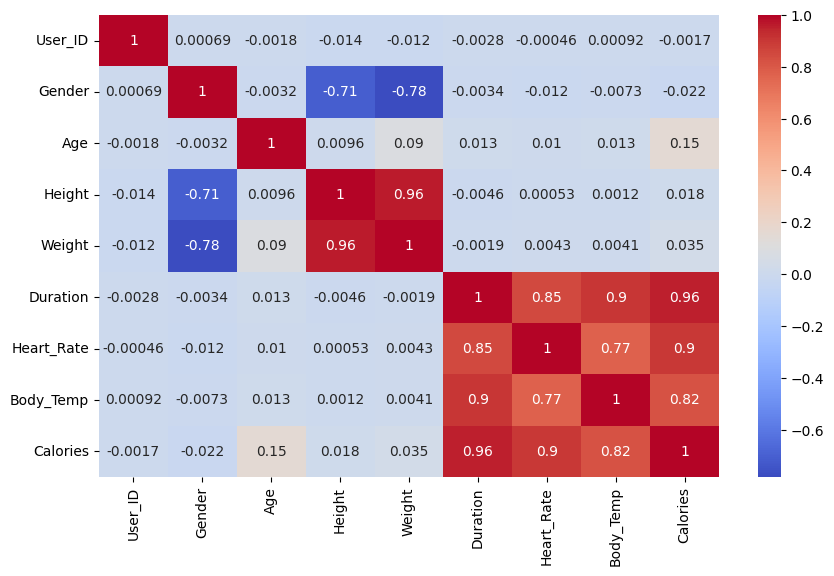

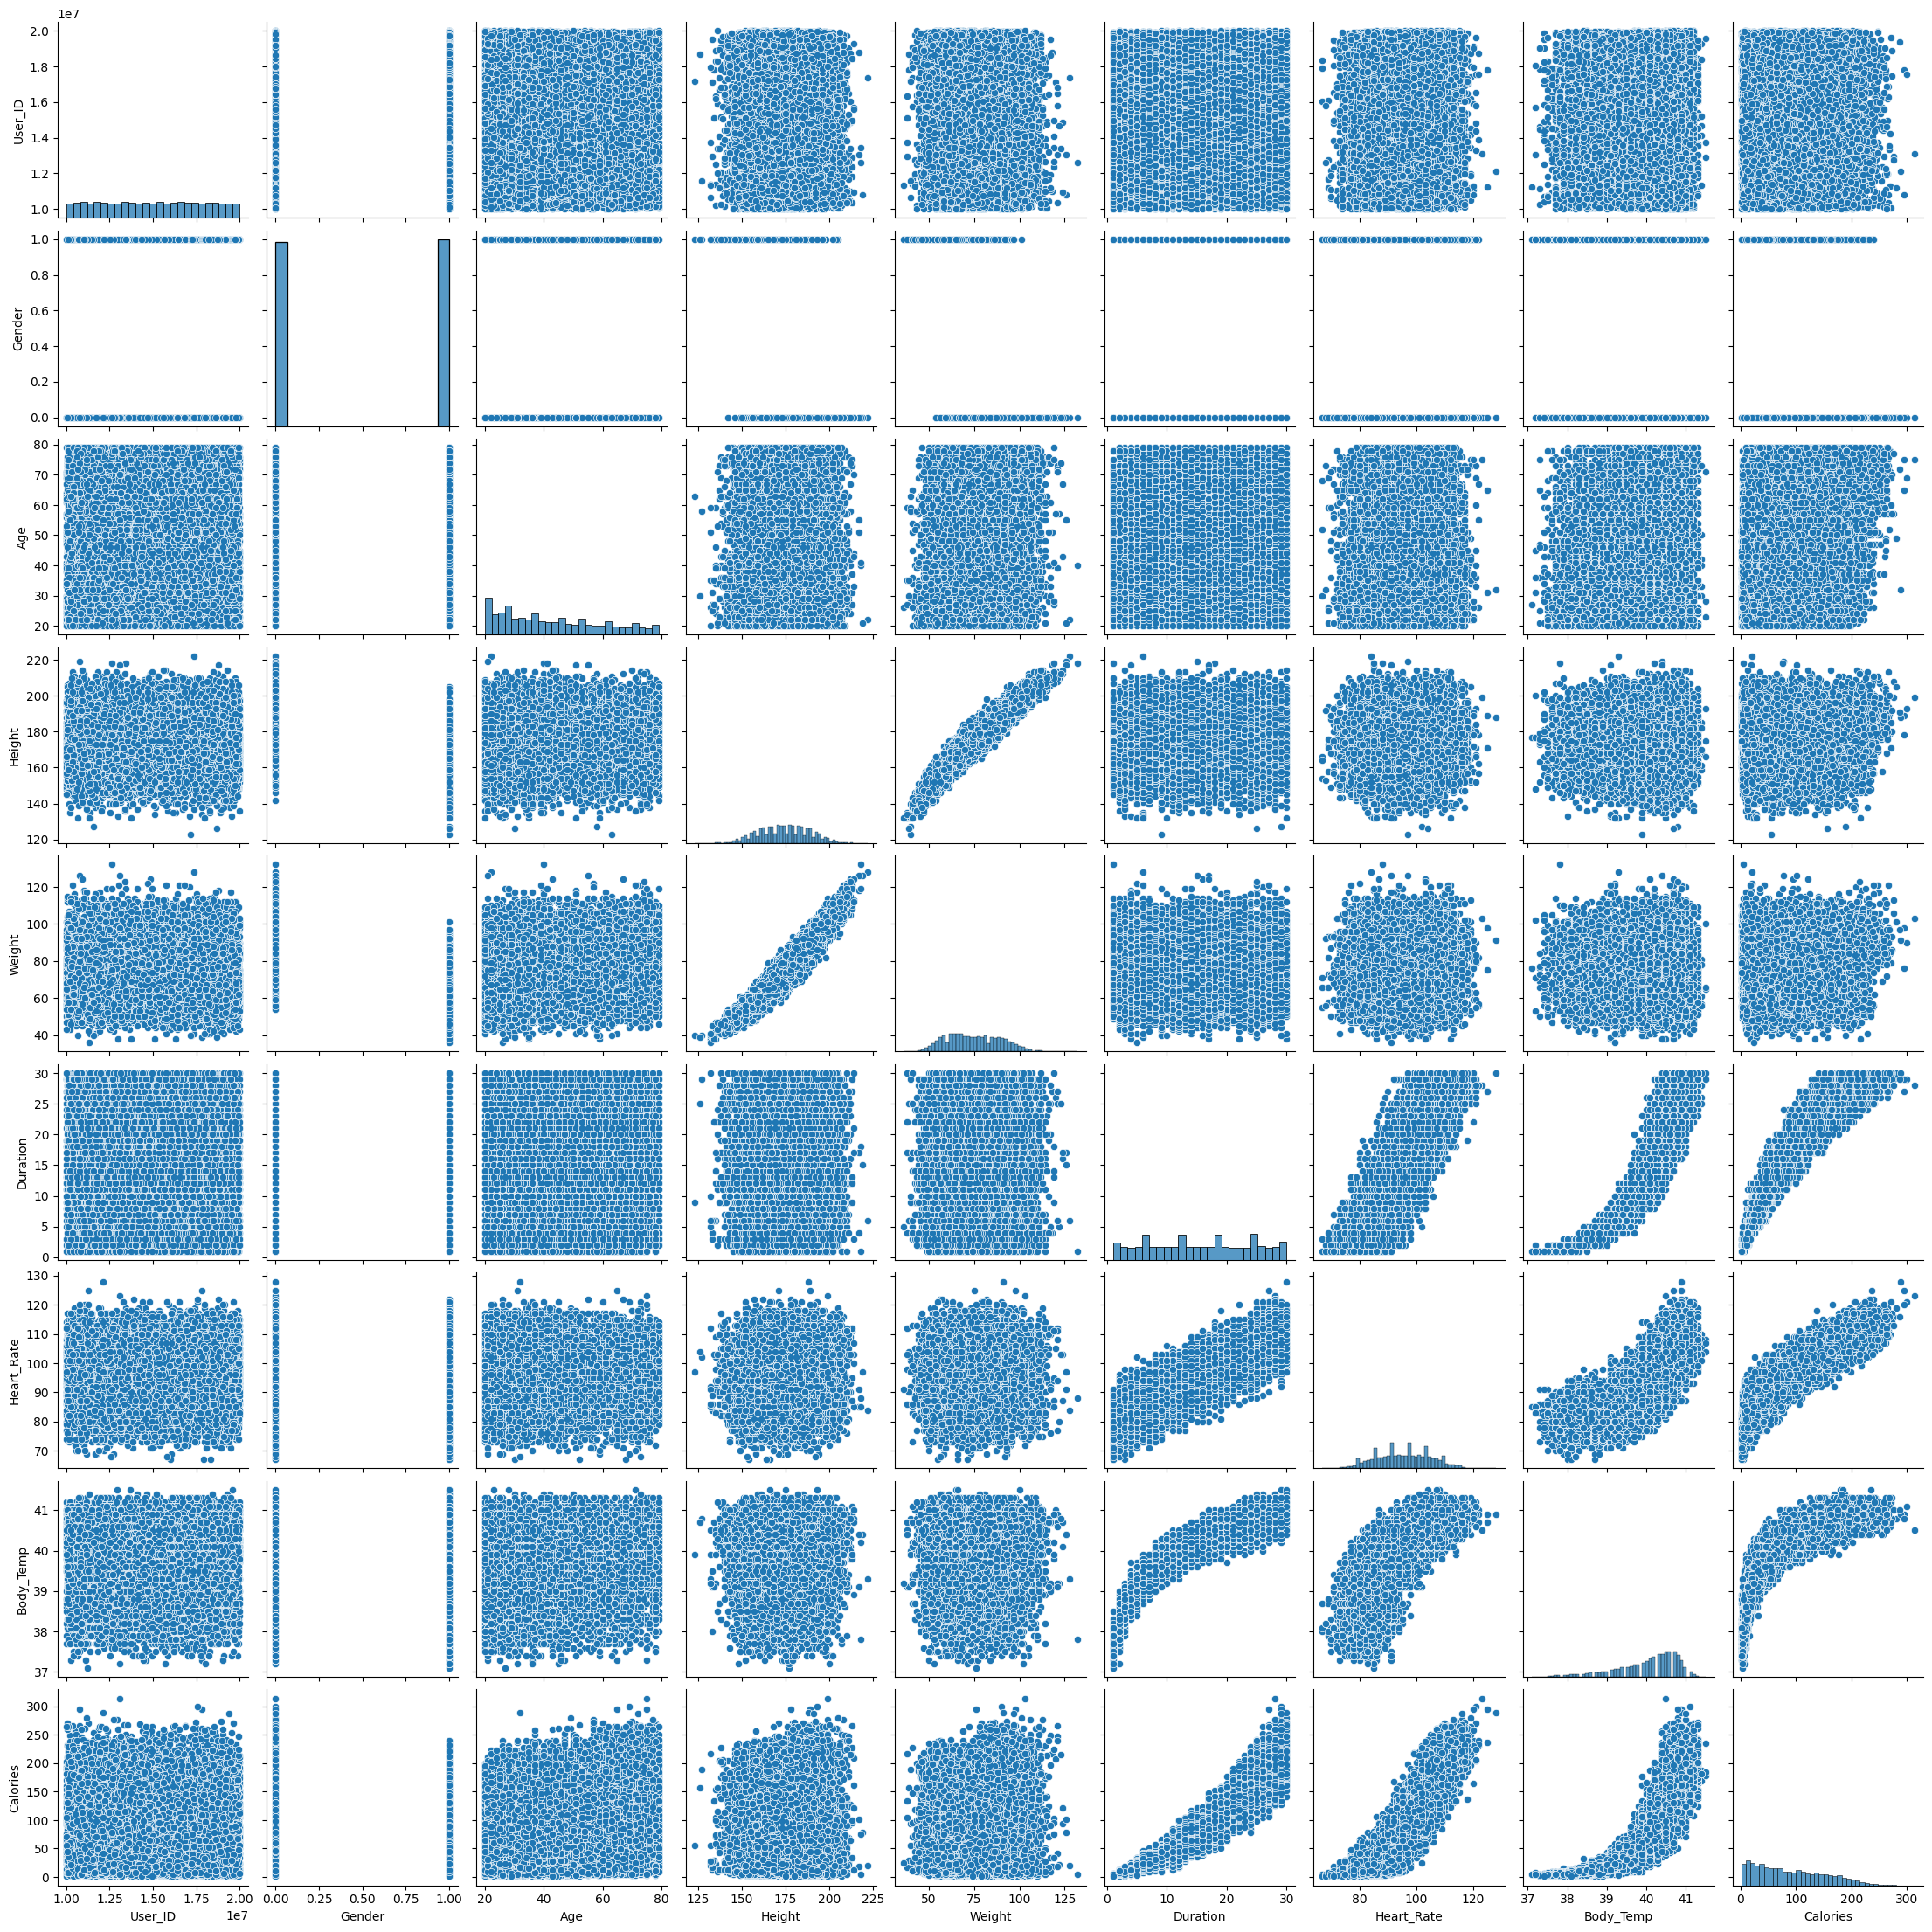

In [16]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

sns.pairplot(df)
plt.show()

In [17]:
# Create BMI Feature
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# Features
X = df[['Gender', 'Age', 'Height', 'Weight',
        'Duration', 'Heart_Rate', 'Body_Temp', 'BMI']]

# Target
y = df['Calories']

X.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI
0,0,68,190.0,94.0,29.0,105.0,40.8,26.038781
1,1,20,166.0,60.0,14.0,94.0,40.3,21.773842
2,0,69,179.0,79.0,5.0,88.0,38.7,24.655910
3,1,34,179.0,71.0,13.0,100.0,40.5,22.159109
4,1,27,154.0,58.0,10.0,81.0,39.8,24.456063


In [18]:
# Model Training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
X_test

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI
11499,1,45,154.0,52.0,26.0,107.0,40.6,21.926126
6475,0,21,187.0,90.0,29.0,111.0,40.5,25.737081
13167,0,58,176.0,77.0,11.0,90.0,40.0,24.857955
862,0,35,182.0,89.0,24.0,108.0,40.8,26.868736
5970,1,67,171.0,67.0,29.0,116.0,41.1,22.913033
...,...,...,...,...,...,...,...,...
6216,1,61,166.0,66.0,28.0,106.0,41.0,23.951227
3585,1,73,165.0,66.0,10.0,92.0,40.0,24.242424
10023,1,38,169.0,66.0,20.0,104.0,40.2,23.108435
14044,1,25,163.0,54.0,5.0,86.0,39.2,20.324438


In [20]:
y_test

11499    173.0
6475     189.0
13167     53.0
862      161.0
5970     226.0
         ...  
6216     186.0
3585      53.0
10023    120.0
14044     20.0
12965    214.0
Name: Calories, Length: 3000, dtype: float64

In [21]:
X_train

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI
9839,0,37,179.0,77.0,7.0,81.0,39.5,24.031709
9680,0,23,195.0,87.0,26.0,110.0,40.5,22.879684
7093,0,33,181.0,77.0,12.0,88.0,40.1,23.503556
11293,1,66,156.0,54.0,9.0,77.0,39.5,22.189349
820,1,32,144.0,49.0,5.0,90.0,39.0,23.630401
...,...,...,...,...,...,...,...,...
5191,1,75,148.0,51.0,22.0,104.0,40.6,23.283419
13418,1,21,172.0,67.0,20.0,104.0,40.7,22.647377
5390,0,57,189.0,92.0,8.0,90.0,39.5,25.755158
860,0,35,174.0,76.0,12.0,97.0,40.2,25.102391


In [22]:
y_train

9839      17.0
9680     167.0
7093      40.0
11293     34.0
820       23.0
         ...  
5191     151.0
13418    114.0
5390      41.0
860       57.0
7270      59.0
Name: Calories, Length: 12000, dtype: float64

In [23]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [24]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [25]:
# Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

print('Linear Regression:')
print('MAE:', mean_absolute_error(y_test, y_pred_lr))
print('R2:', r2_score(y_test, y_pred_lr))

print('\nRandom Forest:')
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('R2:', r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 8.19487023344325
R2: 0.968808193958907

Random Forest:
MAE: 1.7876966666666665
R2: 0.9980902111494225


In [30]:
import pandas as pd

# 1. DEFINE YOUR VARIABLES FIRST
weight = 70       # example weight in kg
height = 175      # example height in cm
age = 25          # example age
gender = "male"   # example gender
duration = 30     # example duration
heart_rate = 110  # example heart rate
body_temp = 37.5  # example body temperature

# 2. Calculate BMI
# Formula: BMI = weight / (height/100)^2
bmi = weight / ((height / 100) ** 2)

# 3. Convert gender into numeric value
gender_value = 1 if gender.lower() == "male" else 0

# 4. Create DataFrame
features = pd.DataFrame([{
    'Gender': gender_value,
    'Age': age,
    'Height': height,
    'Weight': weight,
    'Duration': duration,
    'Heart_Rate': heart_rate,
    'Body_Temp': body_temp,
    'BMI': bmi
}])

# 5. Predict (Ensure 'model' is already trained/defined)
prediction = model.predict(features)
print(prediction)

[187.86]


In [29]:
from sklearn.ensemble import RandomForestRegressor
import pickle

# Create model
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

# Save model
pickle.dump(model, open("calories_model.pkl", "wb"))

print("Model saved successfully")

Model saved successfully


#  Streamlit Deployment Code

In [31]:
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open('calories_model.pkl', 'rb'))

st.title("🔥 Calories Burn Predictor")

# Inputs
gender = st.selectbox("Gender", ["Male", "Female"])

age = st.number_input("Age", min_value=1, max_value=100)

height = st.number_input("Height (cm)", min_value=50.0)

weight = st.number_input("Weight (kg)", min_value=10.0)

duration = st.number_input("Exercise Duration (min)", min_value=1)

heart_rate = st.number_input("Heart Rate", min_value=40)

body_temp = st.number_input("Body Temperature (°C)", min_value=35.0)

# Encode gender
gender = 0 if gender == "male" else 1

# BMI
bmi = weight / ((height / 100) ** 2)

# Prediction
if st.button("Predict Calories"):

    features = np.array([[
        gender,
        age,
        height,
        weight,
        duration,
        heart_rate,
        body_temp,
        bmi
    ]])

    prediction = model.predict(features)

    st.success(f"🔥 Estimated Calories Burned: {prediction[0]:.2f}")

2026-05-07 11:52:55.996 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.257 
  command:

    streamlit run /opt/miniconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-07 11:52:56.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:52:56.259 Thread 'MainThread': 

In [32]:
st.sidebar.title("🔥 Calories Predictor")
st.sidebar.markdown("Enter your fitness details")

2026-05-07 11:53:00.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:00.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:00.455 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:00.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:00.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:00.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

In [33]:
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", 1, 100)

with col2:
    weight = st.number_input("Weight (kg)", 10, 200)

2026-05-07 11:53:03.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:03.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [34]:
st.markdown("""
<h1 style='text-align: center;
color: white;
background: linear-gradient(to right, #ff512f, #dd2476);
padding: 15px;
border-radius: 10px;'>
🔥 Calories Burn Prediction
</h1>
""", unsafe_allow_html=True)

2026-05-07 11:53:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:05.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [35]:
st.image(
    "https://images.unsplash.com/photo-1517836357463-d25dfeac3438",
    use_container_width=True
)

2026-05-07 11:53:08.896 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-07 11:53:08.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:08.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:08.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 11:53:08.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()